In [1]:
######### PACKAGE AND FILE IMPORT ##########

import numpy as np
from numpy.linalg import pinv
from scipy.integrate import solve_ivp
from scipy.linalg import lstsq
import matplotlib.pyplot as plt # type: ignore[import]
from matplotlib.path import Path  # type: ignore[import]
from matplotlib import colors
from matplotlib.animation import FuncAnimation
import pickle

from fish import Fish
from environment import Environment

In [85]:
########## ONE FISH CLOSED-LOOP ##########

# Define the environment containing the fish
Nemo = Fish('Nemo.json')
school = [Nemo]
fish_tank = Environment(school)

# Load simulation outputs
with open('one_fish_CL.pkl', 'rb') as f:
    sim_output = pickle.load(f)
with open('one_fish_CL_Gamma.pkl', 'rb') as f:
    sim_output_Gamma = pickle.load(f)
with open('one_fish_CL_bvs.pkl', 'rb') as f:
    sim_output_bvs = pickle.load(f)
with open('one_fish_CL_bvs_gamma.pkl', 'rb') as f:
    sim_output_bvs_gamma = pickle.load(f)

# Load control inputs
with open('one_fish_CL_control_input.pkl', 'rb') as f:
    control_input = pickle.load(f)

# Extract path taken by head positions
fish_path = np.zeros((2, fish_tank.time_N))
for ii in range(fish_tank.time_N):
    state = sim_output[ii]
    fish_path[0, ii] = state[0]
    fish_path[1, ii] = state[1]

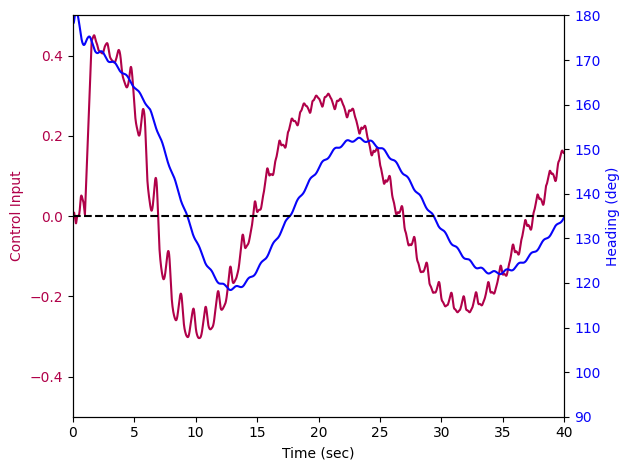

In [86]:
########## PLOT CONTROL INPUT ##########

# Plot fish trajectory
from scipy.signal import savgol_filter

# Time of simulation
time_array = np.linspace(0, fish_tank.t_max, fish_tank.time_N)

# COmpute heading over time
sim_heading = np.zeros(fish_tank.time_N)
smooth_heading = np.zeros(fish_tank.time_N)
for ii in range(fish_tank.time_N):
    state_size = int(len(sim_output[ii])/2)
    current_state = sim_output[ii].reshape((2, state_size), order='F')
    tip_head = current_state[:, 0] # tip of head
    end_head = current_state[:, 2] # end of the head
    heading_vec = tip_head - end_head
    sim_heading[ii] = np.rad2deg(np.mod(np.arctan2(heading_vec[1], heading_vec[0]), 2*np.pi))

# Smooth heading over one flapping cycle
smoothing_window = int(np.round(2 * np.pi / fish_tank.delta_T))
smooth_heading[0] = sim_heading[0] 
for ii in range(fish_tank.time_N):
    if ii < smoothing_window:
        if ii > 0:
            smooth_heading[ii] = np.mean(sim_heading[:ii])
    else:
        smooth_heading[ii] = np.mean(sim_heading[(ii - smoothing_window + 1):ii+1])

# Plot heading error and control effort
fig, ax1 = plt.subplots()
color1 = 'xkcd:raspberry'
color2 = 'xkcd:primary blue'

# Plot control input over time
ax1.set_xlabel('Time (sec)')
ax1.set_ylabel('Control Input', color=color1)
ax1.plot(time_array, control_input, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
plt.xlim([0,40])
plt.ylim([-0.5,0.5])

# Plot heading error over time
ax2 = ax1.twinx()
ax2.set_ylabel('Heading (deg)', color=color2)
ax2.plot(time_array, smooth_heading, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Dashed line show equilibrium condition for both plots
ax2.hlines(y=135, xmin=time_array[0], xmax=time_array[-1], color='black', linestyle='--')
plt.ylim([90,180])
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()


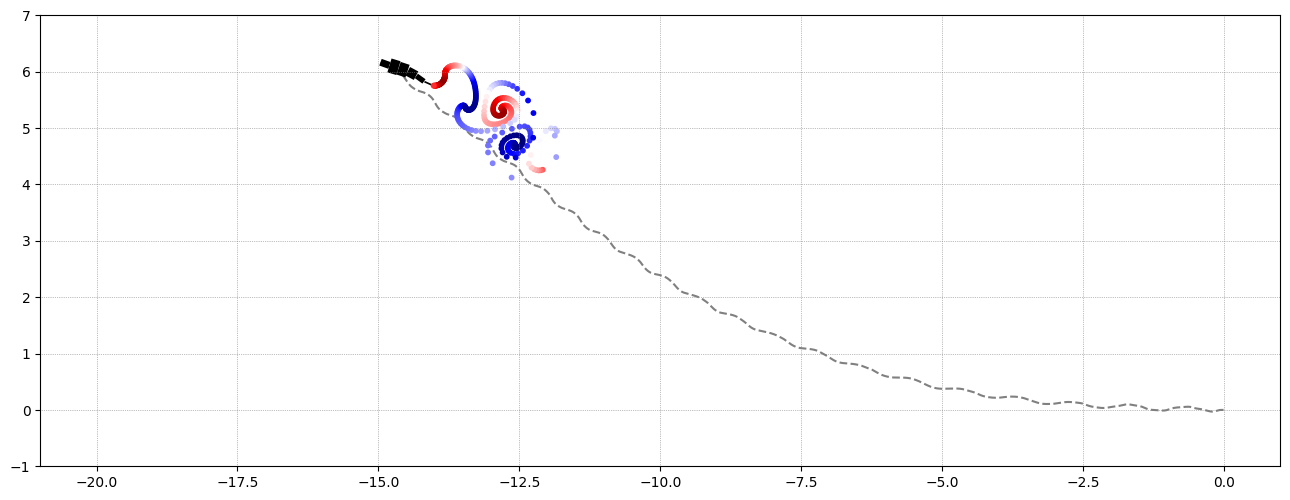

In [99]:
########## PLOT ENVIRONMENT AT ONE TIME INSTANCE ##########

# Preset vortex color maps
all_Gamma = np.concatenate(sim_output_Gamma)
vmin = np.min(all_Gamma)
vmax = np.max(all_Gamma)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap('seismic') 

# Define figure
fig, ax = plt.subplots(figsize=(16, 9))
plt.grid(True, color='gray', linestyle=':', linewidth=0.5)

# Plot fishies at given time
ii = 4250

# Clear image and update state at each time step
ax.clear()
current_state = sim_output[ii]
current_Gamma = sim_output_Gamma[ii]
current_bvs_positions = sim_output_bvs[ii]
current_bvs_gamma = sim_output_bvs_gamma[ii]

# Plot fish trajectory
plt.plot(fish_path[0, :ii], fish_path[1, :ii], color='gray', linestyle='--', zorder=0)

# Plot each fish configuration
start = 0
for fish in [Nemo]:

    end = start + 2*fish.N

    # Get node positions from ODE output
    positions = current_state[start:end].reshape((2,fish.N), order='F')

    # Calculate centerline segment positions and orientations
    midpoints = (positions[:,0:fish.N-1] + positions[:,1:fish.N])/2
    edges = positions[:,1:fish.N] - positions[:,0:fish.N-1]
    tangents = edges/np.linalg.norm(edges, axis=0)
    normals = np.vstack([-tangents[1,:], tangents[0,:]])

    # Caluclate rectangular segment locations 
    southwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T
    northwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    northeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    southeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T

    # Draw rectangular segments
    for jj in range(fish.N-1):
        rectangleX = [southwestPoints[0, jj], northwestPoints[0, jj],
                    northeastPoints[0, jj], southeastPoints[0, jj]]
        rectangleY = [southwestPoints[1, jj], northwestPoints[1, jj],
                    northeastPoints[1, jj], southeastPoints[1, jj]]
        ax.fill(rectangleX, rectangleY, 'k') #, label='Segments' if jj == 0 else "")

    start = end + 2*fish.N

# Plot free vortex street
vortex_data = current_state[start:]
num_vortices = vortex_data.size // 2
free_vortices = vortex_data.reshape((2,num_vortices), order='F')
sc = ax.scatter(free_vortices[0,:], free_vortices[1,:], c=current_Gamma, 
cmap=cmap, norm=norm, s=10)

# For zoomed in figure
# plt.plot([-25,-35],[15.2,25.2], color='gray', linestyle=':', zorder=0)

# Plotting parameters
plt.xlim(-21.0,1.0)
plt.ylim(-1,7)
ax.set_aspect('equal')
ax.grid(True)
# ax.legend()

In [100]:
########## ONE FISH OPEN-LOOP ##########

# Define the environment containing the fish
Nemo = Fish('Nemo.json')
school = [Nemo]
fish_tank = Environment(school)

# Load simulation outputs
with open('one_fish_OL.pkl', 'rb') as f:
    sim_output = pickle.load(f)
with open('one_fish_OL_Gamma.pkl', 'rb') as f:
    sim_output_Gamma = pickle.load(f)
with open('one_fish_OL_bvs.pkl', 'rb') as f:
    sim_output_bvs = pickle.load(f)
with open('one_fish_OL_bvs_gamma.pkl', 'rb') as f:
    sim_output_bvs_gamma = pickle.load(f)

# Extract path taken by head positions
fish_path = np.zeros((2, fish_tank.time_N))
for ii in range(fish_tank.time_N):
    state = sim_output[ii]
    fish_path[0, ii] = state[0]
    fish_path[1, ii] = state[1]

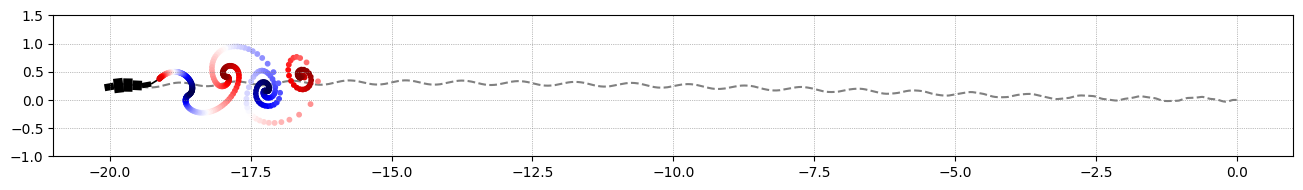

In [103]:
########## PLOT ENVIRONMENT AT ONE TIME INSTANCE ##########

# Preset vortex color maps
all_Gamma = np.concatenate(sim_output_Gamma)
vmin = np.min(all_Gamma)
vmax = np.max(all_Gamma)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap('seismic') 

# Define figure
fig, ax = plt.subplots(figsize=(16, 9))
plt.grid(True, color='gray', linestyle=':', linewidth=0.5)

# Plot fishies at given time
ii = 4000

# Clear image and update state at each time step
ax.clear()
current_state = sim_output[ii]
current_Gamma = sim_output_Gamma[ii]
current_bvs_positions = sim_output_bvs[ii]
current_bvs_gamma = sim_output_bvs_gamma[ii]

# Plot fish trajectory
plt.plot(fish_path[0, :ii], fish_path[1, :ii], color='gray', linestyle='--', zorder=0)

# Plot each fish configuration
start = 0
for fish in [Nemo]:

    end = start + 2*fish.N

    # Get node positions from ODE output
    positions = current_state[start:end].reshape((2,fish.N), order='F')

    # Calculate centerline segment positions and orientations
    midpoints = (positions[:,0:fish.N-1] + positions[:,1:fish.N])/2
    edges = positions[:,1:fish.N] - positions[:,0:fish.N-1]
    tangents = edges/np.linalg.norm(edges, axis=0)
    normals = np.vstack([-tangents[1,:], tangents[0,:]])

    # Caluclate rectangular segment locations 
    southwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T
    northwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    northeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    southeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T

    # Draw rectangular segments
    for jj in range(fish.N-1):
        rectangleX = [southwestPoints[0, jj], northwestPoints[0, jj],
                    northeastPoints[0, jj], southeastPoints[0, jj]]
        rectangleY = [southwestPoints[1, jj], northwestPoints[1, jj],
                    northeastPoints[1, jj], southeastPoints[1, jj]]
        ax.fill(rectangleX, rectangleY, 'k') #, label='Segments' if jj == 0 else "")

    start = end + 2*fish.N

# Plot free vortex street
vortex_data = current_state[start:]
num_vortices = vortex_data.size // 2
free_vortices = vortex_data.reshape((2,num_vortices), order='F')
sc = ax.scatter(free_vortices[0,:], free_vortices[1,:], c=current_Gamma, 
cmap=cmap, norm=norm, s=10)

# Plotting parameters
plt.xlim(-21.0,1.0)
plt.ylim(-1.0,1.5)
ax.set_aspect('equal')
ax.grid(True)
# ax.legend()

In [26]:
########## TWO FISH CLOSED-LOOP ##########

# Define the environment containing the fish
Nemo = Fish('Nemo.json')
Dory = Fish('Dory.json')
school = [Nemo, Dory]
fish_tank = Environment(school)

# Load simulation outputs
with open('two_fish_CL.pkl', 'rb') as f:
    sim_output = pickle.load(f)
with open('two_fish_CL_Gamma.pkl', 'rb') as f:
    sim_output_Gamma = pickle.load(f)
with open('two_fish_CL_bvs.pkl', 'rb') as f:
    sim_output_bvs = pickle.load(f)
with open('two_fish_CL_bvs_gamma.pkl', 'rb') as f:
    sim_output_bvs_gamma = pickle.load(f)

# Extract path taken by head positions
Nemo_path = np.zeros((2, fish_tank.time_N))
Dory_path = np.zeros((2, fish_tank.time_N))
for ii in range(fish_tank.time_N):
    state = sim_output[ii]
    Nemo_path[0, ii] = state[0]
    Nemo_path[1, ii] = state[1]
    Dory_path[0, ii] = state[28]
    Dory_path[1, ii] = state[29]

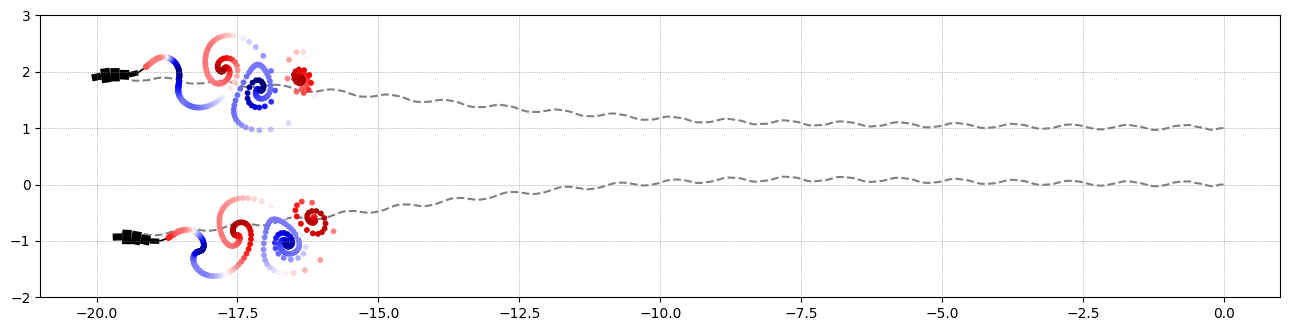

In [38]:
########## PLOT ENVIRONMENT AT ONE TIME INSTANCE ##########

# Preset vortex color maps
all_Gamma = np.concatenate(sim_output_Gamma)
vmin = np.min(all_Gamma)
vmax = np.max(all_Gamma)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap('seismic') 

# Define figure
fig, ax = plt.subplots(figsize=(16, 9))
plt.grid(True, color='gray', linestyle=':', linewidth=0.5)

# Plot fishies at given time
ii = 4000

# Clear image and update state at each time step
ax.clear()
current_state = sim_output[ii]
current_Gamma = sim_output_Gamma[ii]
current_bvs_positions = sim_output_bvs[ii]
current_bvs_gamma = sim_output_bvs_gamma[ii]

# Plot fish trajectory
plt.plot(Nemo_path[0, :ii], Nemo_path[1, :ii], color='gray', linestyle='--', zorder=0)
plt.plot(Dory_path[0, :ii], Dory_path[1, :ii], color='gray', linestyle='--', zorder=0)

# Plot each fish configuration
start = 0
for fish in [Nemo, Dory]:

    end = start + 2*fish.N

    # Get node positions from ODE output
    positions = current_state[start:end].reshape((2,fish.N), order='F')

    # Calculate centerline segment positions and orientations
    midpoints = (positions[:,0:fish.N-1] + positions[:,1:fish.N])/2
    edges = positions[:,1:fish.N] - positions[:,0:fish.N-1]
    tangents = edges/np.linalg.norm(edges, axis=0)
    normals = np.vstack([-tangents[1,:], tangents[0,:]])

    # Caluclate rectangular segment locations 
    southwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T
    northwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    northeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    southeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T

    # Draw rectangular segments
    for jj in range(fish.N-1):
        rectangleX = [southwestPoints[0, jj], northwestPoints[0, jj],
                    northeastPoints[0, jj], southeastPoints[0, jj]]
        rectangleY = [southwestPoints[1, jj], northwestPoints[1, jj],
                    northeastPoints[1, jj], southeastPoints[1, jj]]
        ax.fill(rectangleX, rectangleY, 'k') #, label='Segments' if jj == 0 else "")

    start = end + 2*fish.N

# Plot free vortex street
vortex_data = current_state[start:]
num_vortices = vortex_data.size // 2
free_vortices = vortex_data.reshape((2,num_vortices), order='F')
sc = ax.scatter(free_vortices[0,:], free_vortices[1,:], c=current_Gamma, 
cmap=cmap, norm=norm, s=10)

# Plotting parameters
plt.xlim(-21,1)
plt.ylim(-2.0,3.0)
ax.set_aspect('equal')
ax.grid(True)
# ax.legend()

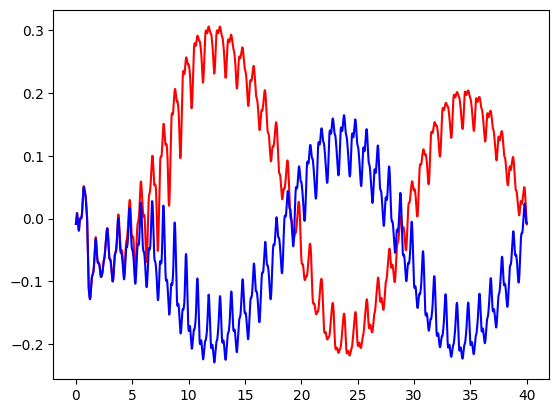

In [40]:
########## PLOT CONTROL INPUT ##########

# Plot fish trajectory
from scipy.signal import savgol_filter

with open('Nemo_two_fish_CL_control_input.pkl', 'rb') as f:
    Nemo_control_input = pickle.load(f)
with open('Dory_two_fish_CL_control_input.pkl', 'rb') as f:
    Dory_control_input = pickle.load(f)

plt.plot(np.linspace(0, fish_tank.t_max, fish_tank.time_N), Nemo_control_input, color='red', linestyle='-', zorder=0)
plt.plot(np.linspace(0, fish_tank.t_max, fish_tank.time_N), Dory_control_input, color='blue', linestyle='-', zorder=0) 

In [56]:
########## TWO FISH OPEN-LOOP ##########

# Define the environment containing the fish
Nemo = Fish('Nemo.json')
Dory = Fish('Dory.json')
school = [Nemo, Dory]
fish_tank = Environment(school)

# Load simulation outputs
with open('two_fish_OL.pkl', 'rb') as f:
    sim_output = pickle.load(f)
with open('two_fish_OL_Gamma.pkl', 'rb') as f:
    sim_output_Gamma = pickle.load(f)
with open('two_fish_OL_bvs.pkl', 'rb') as f:
    sim_output_bvs = pickle.load(f)
with open('two_fish_OL_bvs_gamma.pkl', 'rb') as f:
    sim_output_bvs_gamma = pickle.load(f)

# Extract path taken by head positions
Nemo_path = np.zeros((2, fish_tank.time_N))
Dory_path = np.zeros((2, fish_tank.time_N))
for ii in range(fish_tank.time_N):
    state = sim_output[ii]
    Nemo_path[0, ii] = state[0]
    Nemo_path[1, ii] = state[1]
    Dory_path[0, ii] = state[28]
    Dory_path[1, ii] = state[29]

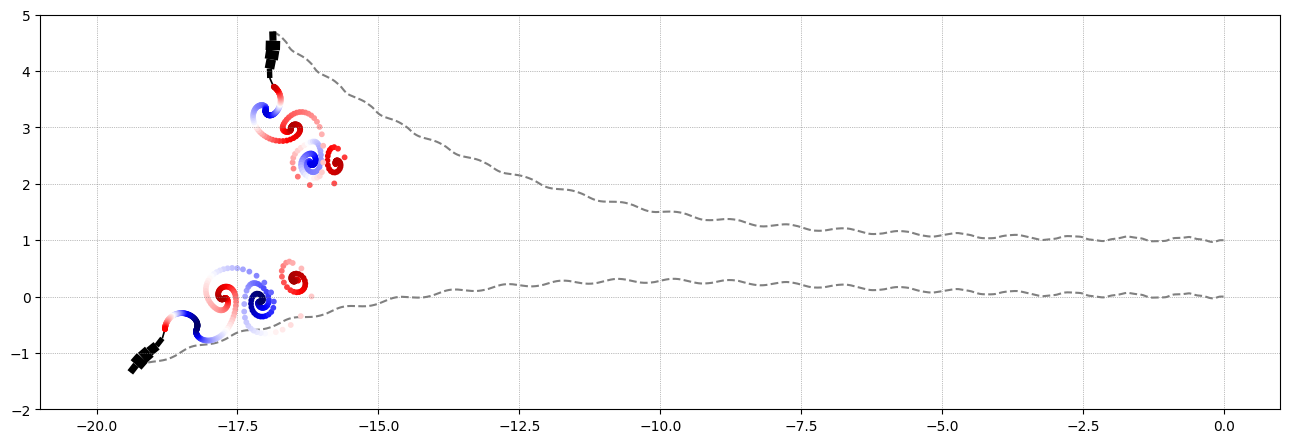

In [58]:
########## PLOT ENVIRONMENT AT ONE TIME INSTANCE ##########

# Preset vortex color maps
all_Gamma = np.concatenate(sim_output_Gamma)
vmin = np.min(all_Gamma)
vmax = np.max(all_Gamma)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap('seismic') 

# Define figure
fig, ax = plt.subplots(figsize=(16, 9))
plt.grid(True, color='gray', linestyle=':', linewidth=0.5)

# Plot fishies at given time
ii = 4000

# Clear image and update state at each time step
ax.clear()
current_state = sim_output[ii]
current_Gamma = sim_output_Gamma[ii]
current_bvs_positions = sim_output_bvs[ii]
current_bvs_gamma = sim_output_bvs_gamma[ii]

# Plot fish trajectory
plt.plot(Nemo_path[0, :ii], Nemo_path[1, :ii], color='gray', linestyle='--', zorder=0)
plt.plot(Dory_path[0, :ii], Dory_path[1, :ii], color='gray', linestyle='--', zorder=0)

# Plot each fish configuration
start = 0
for fish in [Nemo, Dory]:

    end = start + 2*fish.N

    # Get node positions from ODE output
    positions = current_state[start:end].reshape((2,fish.N), order='F')

    # Calculate centerline segment positions and orientations
    midpoints = (positions[:,0:fish.N-1] + positions[:,1:fish.N])/2
    edges = positions[:,1:fish.N] - positions[:,0:fish.N-1]
    tangents = edges/np.linalg.norm(edges, axis=0)
    normals = np.vstack([-tangents[1,:], tangents[0,:]])

    # Caluclate rectangular segment locations 
    southwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T
    northwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    northeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    southeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T

    # Draw rectangular segments
    for jj in range(fish.N-1):
        rectangleX = [southwestPoints[0, jj], northwestPoints[0, jj],
                    northeastPoints[0, jj], southeastPoints[0, jj]]
        rectangleY = [southwestPoints[1, jj], northwestPoints[1, jj],
                    northeastPoints[1, jj], southeastPoints[1, jj]]
        ax.fill(rectangleX, rectangleY, 'k') #, label='Segments' if jj == 0 else "")

    start = end + 2*fish.N

# Plot free vortex street
vortex_data = current_state[start:]
num_vortices = vortex_data.size // 2
free_vortices = vortex_data.reshape((2,num_vortices), order='F')
sc = ax.scatter(free_vortices[0,:], free_vortices[1,:], c=current_Gamma, 
cmap=cmap, norm=norm, s=10)

# Plotting parameters
plt.xlim(-21.0,1.0)
plt.ylim(-2,5)
ax.set_aspect('equal')
ax.grid(True)
# ax.legend()

In [ ]:
########## FOUR FISH OPEN-LOOP ##########

# Define the environment containing the fish
OneFish = Fish('one_fish.json')
TwoFish = Fish('two_fish.json')
RedFish = Fish('red_fish.json')
BlueFish = Fish('blue_fish.json')
school = [OneFish, TwoFish, RedFish, BlueFish]
fish_tank = Environment(school)

# Load simulation outputs
with open('dr_seuss.pkl', 'rb') as f:
    sim_output = pickle.load(f)
with open('dr_seuss_Gamma.pkl', 'rb') as f:
    sim_output_Gamma = pickle.load(f)
with open('dr_seuss_bvs.pkl', 'rb') as f:
    sim_output_bvs = pickle.load(f)
with open('dr_seuss_bvs_gamma.pkl', 'rb') as f:
    sim_output_bvs_gamma = pickle.load(f)

# Extract path taken by head positions
OneFish_path = np.zeros((2, fish_tank.time_N))
TwoFish_path = np.zeros((2, fish_tank.time_N))
RedFish_path = np.zeros((2, fish_tank.time_N))
BlueFish_path = np.zeros((2, fish_tank.time_N))
for ii in range(fish_tank.time_N):
    state = sim_output[ii]
    OneFish_path[0, ii] = state[0]
    OneFish_path[1, ii] = state[1]
    TwoFish_path[0, ii] = state[4*7]
    TwoFish_path[1, ii] = state[4*7+1]
    RedFish_path[0, ii] = state[2*4*7]
    RedFish_path[1, ii] = state[2*4*7+1]
    BlueFish_path[0, ii] = state[3*4*7]
    BlueFish_path[1, ii] = state[3*4*7+1]

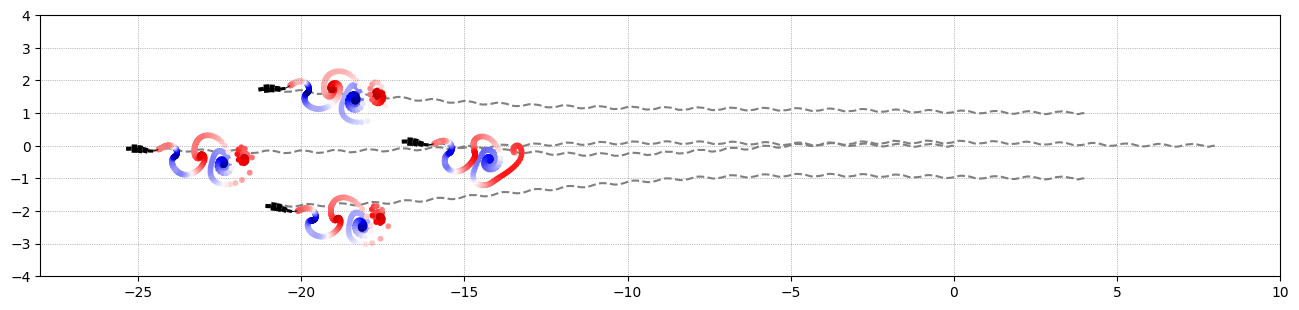

In [3]:
########## PLOT ENVIRONMENT AT ONE TIME INSTANCE ##########

# Preset vortex color maps
all_Gamma = np.concatenate(sim_output_Gamma)
vmin = np.min(all_Gamma)
vmax = np.max(all_Gamma)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap('seismic') 

# Define figure
fig, ax = plt.subplots(figsize=(16, 9))
plt.grid(True, color='gray', linestyle=':', linewidth=0.5)

# Plot fishies at given time
ii = 5000

# Clear image and update state at each time step
ax.clear()
current_state = sim_output[ii]
current_Gamma = sim_output_Gamma[ii]
current_bvs_positions = sim_output_bvs[ii]
current_bvs_gamma = sim_output_bvs_gamma[ii]

# Plot fish trajectory
plt.plot(OneFish_path[0, :ii], OneFish_path[1, :ii], color='gray', linestyle='--', zorder=0)
plt.plot(TwoFish_path[0, :ii], TwoFish_path[1, :ii], color='gray', linestyle='--', zorder=0)
plt.plot(RedFish_path[0, :ii], RedFish_path[1, :ii], color='gray', linestyle='--', zorder=0)
plt.plot(BlueFish_path[0, :ii], BlueFish_path[1, :ii], color='gray', linestyle='--', zorder=0)

# Plot each fish configuration
start = 0
for fish in [OneFish, TwoFish, RedFish, BlueFish]:

    end = start + 2*fish.N

    # Get node positions from ODE output
    positions = current_state[start:end].reshape((2,fish.N), order='F')

    # Calculate centerline segment positions and orientations
    midpoints = (positions[:,0:fish.N-1] + positions[:,1:fish.N])/2
    edges = positions[:,1:fish.N] - positions[:,0:fish.N-1]
    tangents = edges/np.linalg.norm(edges, axis=0)
    normals = np.vstack([-tangents[1,:], tangents[0,:]])

    # Caluclate rectangular segment locations 
    southwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T
    northwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    northeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    southeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T

    # Draw rectangular segments
    for jj in range(fish.N-1):
        rectangleX = [southwestPoints[0, jj], northwestPoints[0, jj],
                    northeastPoints[0, jj], southeastPoints[0, jj]]
        rectangleY = [southwestPoints[1, jj], northwestPoints[1, jj],
                    northeastPoints[1, jj], southeastPoints[1, jj]]
        ax.fill(rectangleX, rectangleY, 'k', zorder=2) #, label='Segments' if jj == 0 else "")

    start = end + 2*fish.N

# Plot free vortex street
vortex_data = current_state[start:]
num_vortices = vortex_data.size // 2
free_vortices = vortex_data.reshape((2,num_vortices), order='F')
sc = ax.scatter(free_vortices[0,:], free_vortices[1,:], c=current_Gamma, 
cmap=cmap, norm=norm, s=10, zorder=1)

# Plotting parameters
plt.xlim(-28, 10)
plt.ylim(-4, 4)
ax.set_aspect('equal')
ax.grid(True)
# ax.legend()

In [4]:
########## FOUR FISH OPEN-LOOP ##########

# Define the environment containing the fish
OneFish = Fish('one_fish.json')
TwoFish = Fish('two_fish.json')
RedFish = Fish('red_fish.json')
BlueFish = Fish('blue_fish.json')
school = [OneFish, TwoFish, RedFish, BlueFish]
fish_tank = Environment(school)

# Load simulation outputs
with open('dr_seuss_OL.pkl', 'rb') as f:
    sim_output = pickle.load(f)
with open('dr_seuss_OL_Gamma.pkl', 'rb') as f:
    sim_output_Gamma = pickle.load(f)
with open('dr_seuss_OL_bvs.pkl', 'rb') as f:
    sim_output_bvs = pickle.load(f)
with open('dr_seuss_OL_bvs_gamma.pkl', 'rb') as f:
    sim_output_bvs_gamma = pickle.load(f)

# Extract path taken by head positions
OneFish_path = np.zeros((2, fish_tank.time_N))
TwoFish_path = np.zeros((2, fish_tank.time_N))
RedFish_path = np.zeros((2, fish_tank.time_N))
BlueFish_path = np.zeros((2, fish_tank.time_N))
for ii in range(fish_tank.time_N):
    state = sim_output[ii]
    OneFish_path[0, ii] = state[0]
    OneFish_path[1, ii] = state[1]
    TwoFish_path[0, ii] = state[4*7]
    TwoFish_path[1, ii] = state[4*7+1]
    RedFish_path[0, ii] = state[2*4*7]
    RedFish_path[1, ii] = state[2*4*7+1]
    BlueFish_path[0, ii] = state[3*4*7]
    BlueFish_path[1, ii] = state[3*4*7+1]

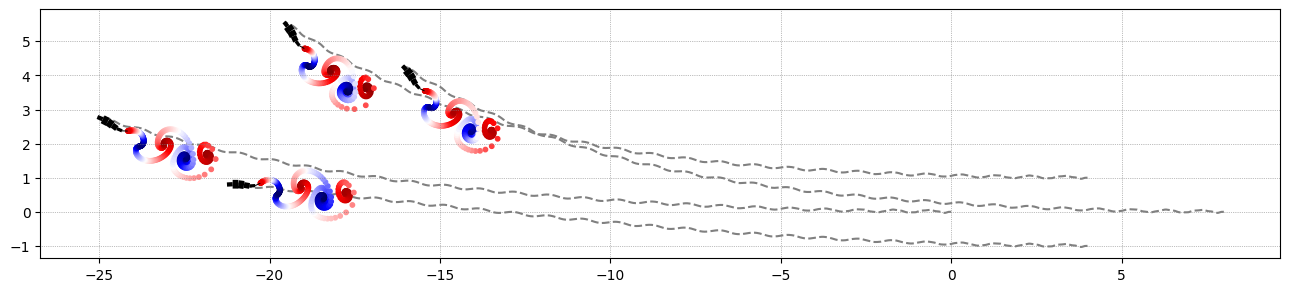

In [6]:
########## PLOT ENVIRONMENT AT ONE TIME INSTANCE ##########

# Preset vortex color maps
all_Gamma = np.concatenate(sim_output_Gamma)
vmin = np.min(all_Gamma)
vmax = np.max(all_Gamma)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap('seismic') 

# Define figure
fig, ax = plt.subplots(figsize=(16, 9))
plt.grid(True, color='gray', linestyle=':', linewidth=0.5)

# Plot fishies at given time
ii = 5000

# Clear image and update state at each time step
ax.clear()
current_state = sim_output[ii]
current_Gamma = sim_output_Gamma[ii]
current_bvs_positions = sim_output_bvs[ii]
current_bvs_gamma = sim_output_bvs_gamma[ii]

# Plot fish trajectory
plt.plot(OneFish_path[0, :ii], OneFish_path[1, :ii], color='gray', linestyle='--', zorder=0)
plt.plot(TwoFish_path[0, :ii], TwoFish_path[1, :ii], color='gray', linestyle='--', zorder=0)
plt.plot(RedFish_path[0, :ii], RedFish_path[1, :ii], color='gray', linestyle='--', zorder=0)
plt.plot(BlueFish_path[0, :ii], BlueFish_path[1, :ii], color='gray', linestyle='--', zorder=0)

# Plot each fish configuration
start = 0
for fish in [OneFish, TwoFish, RedFish, BlueFish]:

    end = start + 2*fish.N

    # Get node positions from ODE output
    positions = current_state[start:end].reshape((2,fish.N), order='F')

    # Calculate centerline segment positions and orientations
    midpoints = (positions[:,0:fish.N-1] + positions[:,1:fish.N])/2
    edges = positions[:,1:fish.N] - positions[:,0:fish.N-1]
    tangents = edges/np.linalg.norm(edges, axis=0)
    normals = np.vstack([-tangents[1,:], tangents[0,:]])

    # Caluclate rectangular segment locations 
    southwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T
    northwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    northeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    southeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T

    # Draw rectangular segments
    for jj in range(fish.N-1):
        rectangleX = [southwestPoints[0, jj], northwestPoints[0, jj],
                    northeastPoints[0, jj], southeastPoints[0, jj]]
        rectangleY = [southwestPoints[1, jj], northwestPoints[1, jj],
                    northeastPoints[1, jj], southeastPoints[1, jj]]
        ax.fill(rectangleX, rectangleY, 'k', zorder=2) #, label='Segments' if jj == 0 else "")

    start = end + 2*fish.N

# Plot free vortex street
vortex_data = current_state[start:]
num_vortices = vortex_data.size // 2
free_vortices = vortex_data.reshape((2,num_vortices), order='F')
sc = ax.scatter(free_vortices[0,:], free_vortices[1,:], c=current_Gamma, 
cmap=cmap, norm=norm, s=10, zorder=1)

# Plotting parameters
# plt.xlim(-28, 10)
# plt.ylim(-4, 4)
ax.set_aspect('equal')
ax.grid(True)
# ax.legend()

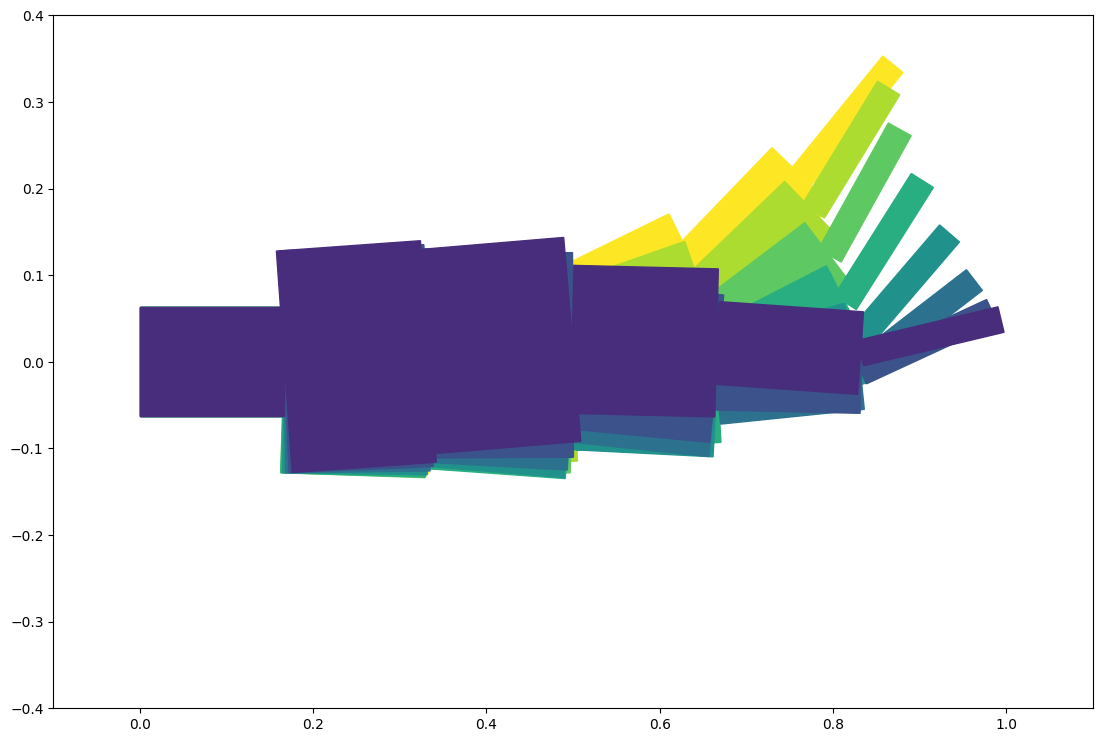

In [8]:
########## SHOWING BENDING BEHAVIOR WITH CONTROL ##########

flappy_fish = Fish('one_fish.json')
N = flappy_fish.N
L = flappy_fish.fish_length
A = flappy_fish.wave_amplitude
omega = flappy_fish.wave_frequency
k = flappy_fish.wave_number
c1 = flappy_fish.c1
c2 = flappy_fish.c2
l_edge = flappy_fish.l_edge_ref
h_edge = flappy_fish.h_edge_ref
recenterline = flappy_fish.recenterline
centerline_scaling = flappy_fish.centerline_scaling

# No heading error, no wave bias
time_N = 8
time_step = np.linspace(-0.25,0.25,time_N)
wave_bias = 0.5

cmap = plt.get_cmap('viridis')

# Define figure
fig, ax = plt.subplots(figsize=(16, 9))
plt.grid(False)

for tt in range(8):

    phi = np.zeros(N-1)
    positions = np.zeros((2,N))

    # Define rest of fish body configuration
    phi[1:] = centerline_scaling * A * (np.sin(k * recenterline + omega * time_step[tt]) + wave_bias)
    current_phi = phi[0]
    for ii in range(N-1):
        positions[:, ii+1] = positions[:, ii] + l_edge[ii] * np.array([np.cos(current_phi), np.sin(current_phi)])
        if ii < N - 2:
            current_phi += phi[ii+1]

    # Calculate centerline segment positions and orientations
    midpoints = (positions[:,0:N-1] + positions[:,1:N])/2
    edges = positions[:,1:N] - positions[:,0:N-1]
    tangents = edges/np.linalg.norm(edges, axis=0)
    normals = np.vstack([-tangents[1,:], tangents[0,:]])

    # Caluclate rectangular segment locations 
    southwestPoints = midpoints - 0.5*tangents*l_edge.T - 0.5*normals*h_edge.T
    northwestPoints = midpoints - 0.5*tangents*l_edge.T + 0.5*normals*h_edge.T
    northeastPoints = midpoints + 0.5*tangents*l_edge.T + 0.5*normals*h_edge.T
    southeastPoints = midpoints + 0.5*tangents*l_edge.T - 0.5*normals*h_edge.T

    # Draw rectangular segments
    for jj in range(N-1):
        rectangleX = [southwestPoints[0, jj], northwestPoints[0, jj],
                    northeastPoints[0, jj], southeastPoints[0, jj]]
        rectangleY = [southwestPoints[1, jj], northwestPoints[1, jj],
                    northeastPoints[1, jj], southeastPoints[1, jj]]
        ax.fill(rectangleX, rectangleY, color=cmap(1 - tt / time_N), zorder=2)

# Plotting parameters
plt.xlim(-0.1,1.1)
plt.ylim(-0.4,0.4)
ax.set_aspect('equal')
# ax.grid(True)